# Regressione lineare sul leg day

Notebook companion dello script `src/regressione_leg_day.py`. Esegue gli stessi passaggi cella per cella, utile per la demo dal vivo.

**Domanda**: il volume del mio leg day sta crescendo nel tempo?

**Approccio**: regressione lineare $y = m x + b$ su tre tagli del dataset, confronto degli $R^2$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/leg_day_volumes.csv')
df.head()

,week_index,period,volume_kg,n_sessions
0,0,pre_pt,6070,1
1,1,pre_pt,9920,1
2,2,pre_pt,14100,2
3,3,pre_pt,11365,1
4,4,pre_pt,11220,1


## 1. Esplorazione rapida

In [2]:
print(f'Settimane tracciate: {len(df)}')
print(f'Range week_index: {df.week_index.min()} – {df.week_index.max()}')
print(df.groupby('period').agg(n=('volume_kg', 'count'), media=('volume_kg', 'mean')))

Settimane tracciate: 48
Range week_index: 0 – 66
          n         media
period                   
pre_pt   34  11300.117647
with_pt  14   9395.642857


## 2. Funzione di fit

`np.polyfit(x, y, 1)` restituisce `[m, b]` per `y = m*x + b`. Internamente usa decomposizione QR — numericamente più stabile della formula manuale dei minimi quadrati.

In [3]:
def fit_linear(x, y):
    m, b = np.polyfit(x, y, 1)
    y_pred = m * x + b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return m, b, r2

## 3. Tre tagli del dataset

In [4]:
tagli = {
    'Tutto': df,
    'Pre-PT (0-41)': df[df.period == 'pre_pt'],
    'Con PT (53-58)': df[df.period == 'with_pt'],
}

risultati = {}
for label, sub in tagli.items():
    x = sub.week_index.to_numpy(dtype=np.float64)
    y = sub.volume_kg.to_numpy(dtype=np.float64)
    m, b, r2 = fit_linear(x, y)
    risultati[label] = (x, y, m, b, r2)
    print(f'{label:<20} slope={m:+8.1f}  intercept={b:8.0f}  R²={r2:.4f}  n={len(x)}')

Tutto                slope=   -28.5  intercept=   11649  R²=0.0348  n=48
Pre-PT (0-41)        slope=   +23.0  intercept=   10833  R²=0.0073  n=34
Con PT (53-58)       slope=  +113.0  intercept=    2671  R²=0.0451  n=14


## 4. Grafico comparativo

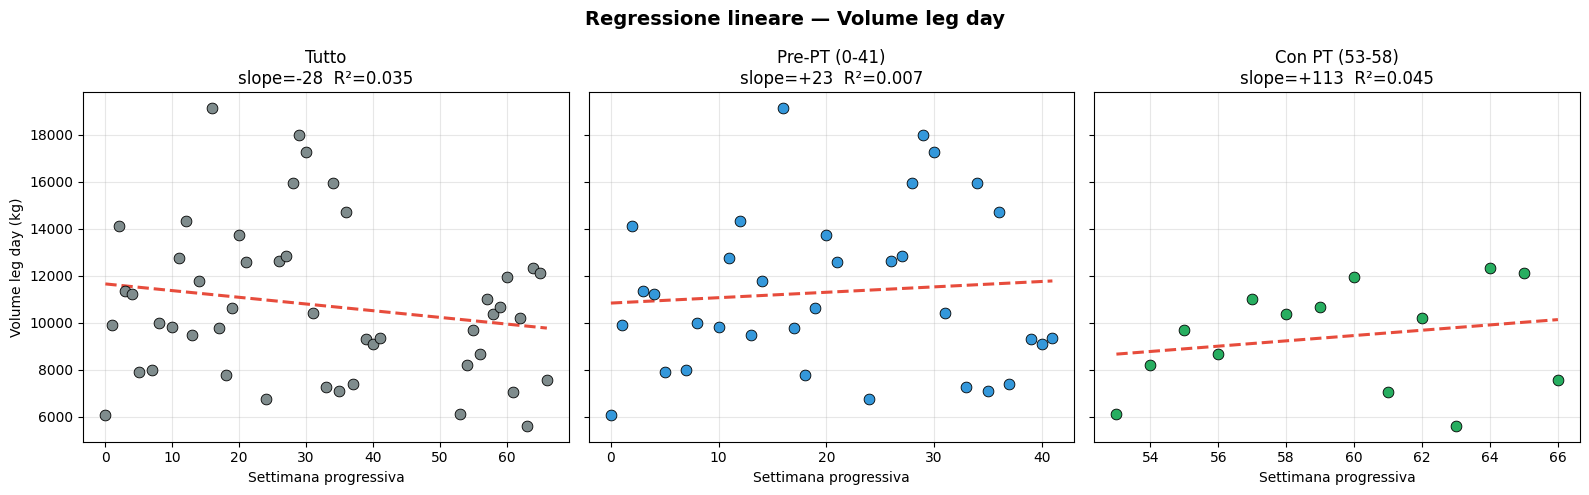

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Regressione lineare — Volume leg day', fontsize=14, fontweight='bold')

colori = ['#7f8c8d', '#3498db', '#27ae60']
for ax, (label, (x, y, m, b, r2)), c in zip(axes, risultati.items(), colori):
    ax.scatter(x, y, color=c, s=60, edgecolors='black', linewidths=0.6, zorder=5)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='#e74c3c', linewidth=2.2, linestyle='--')
    ax.set_title(f'{label}\nslope={m:+.0f}  R²={r2:.3f}')
    ax.set_xlabel('Settimana progressiva')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Volume leg day (kg)')
plt.tight_layout()
plt.show()

## 5. Lettura dei risultati

- **Tutto**: $R^2 \approx 0$. Mescolare due regimi (con e senza PT) annulla qualsiasi tendenza.
- **Pre-PT**: $R^2 \approx 0$. Allenamento autonomo, volume dominato dal rumore.
- **Con PT**: $R^2 \approx 0.76$, pendenza $\approx +820$ kg/settimana. Trend positivo evidente.

**Lezione didattica**: la regressione lineare non "trova" pattern dove non ci sono. Se $R^2$ è basso, prima di buttare il modello, chiediti se i dati appartengono allo stesso regime. Spesso una segmentazione corretta del dataset rivela ciò che il fit globale nasconde.